# 고객 이탈 예측 분석 - Logistic Regression

## 분석 목적
본 분석의 목적은 고객의 카드 사용 행동 데이터를 기반으로 고객 이탈(churn) 여부를 예측하는 것이다.  
특히 Logistic Regression 모델을 활용하여 어떤 변수들이 이탈 확률에 영향을 미치는지 해석 가능한 형태로 확인하고,  
향후 고객 유지 전략 수립에 활용할 수 있는 인사이트를 도출하고자 한다.

## 기대 효과
- 이탈 가능성이 높은 고객군을 사전에 식별할 수 있다.
- 이탈에 영향을 주는 주요 행동 변수를 파악할 수 있다.
- 마케팅, CRM, 고객 유지 캠페인 설계의 근거 자료로 활용할 수 있다.

## 분석 포인트
- 어떤 행동 변수들이 고객 이탈에 가장 큰 영향을 주는가?
- 모델이 이탈 고객과 유지 고객을 어느 정도 구분하는가?
- 계수 해석을 통해 실무적으로 활용 가능한 방향성이 도출되는가?

In [1]:
# 분석 전반에서 사용할 라이브러리를 먼저 불러온다.
# 사전에 모듈을 명시적으로 로드해두면 실행 순서가 달라도 에러를 줄일 수 있다.
# 유지보수 시에는 라이브러리 버전에 따라 결과가 달라질 수 있으므로 requirements 관리가 필요하다.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

## 1. 데이터 로드 및 기초 확인

### 비즈니스 목적
분석에 사용할 데이터를 불러오고, 타깃 변수와 주요 입력 변수들이 정상적으로 존재하는지 확인한다.  
실무에서는 파일 경로, 컬럼명, 데이터 타입 문제로 인해 분석이 중단되는 경우가 많기 때문에  
초기 단계에서 구조를 점검하는 것이 매우 중요하다.

### 분석 포인트
- 데이터가 정상적으로 로드되었는가?
- 분석 대상 컬럼들이 모두 존재하는가?
- 데이터 크기와 컬럼 구성이 기대한 구조와 일치하는가?

In [2]:
# 파일 경로가 잘못되면 이후 모든 분석이 중단되므로 가장 먼저 확인한다.
# 배포 환경에서는 상대경로/절대경로 차이로 오류가 자주 발생하므로 주의한다.

df = pd.read_csv("preprocessed_BankChurners.csv")

print("데이터 크기:", df.shape)
display(df.head())

데이터 크기: (10127, 20)


,churn,age,gender,dependents,education,marital,income,card_type,relationship_months,product_count,inactive_months,contact_count,credit_limit,revolving_balance,available_credit,amount_change,transaction_amount,transaction_count,count_change,utilization_ratio
0,1,45,0,3,2,2,3,1,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,1,5,4,1,1,1,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,0,3,4,2,4,1,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,1,4,2,4,1,1,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,0,3,1,2,3,1,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## 2. 분석 변수 정의

### 비즈니스 목적
고객 이탈 예측에 사용할 핵심 행동 변수를 정의한다.  
모든 변수를 무조건 사용하는 것보다, 해석 가능성과 실무 활용성이 높은 변수 중심으로 모델을 구성하면  
결과를 이해하고 전략으로 연결하기가 훨씬 수월하다.

### 분석 포인트
- target은 `churn`으로 설정한다.
- feature는 카드 사용 행동을 반영하는 7개 변수로 제한한다.
- 변수 정의가 명확해야 모델 결과 해석이 가능하다.

In [3]:
# 모델의 입력 변수와 목표 변수를 명확히 분리한다.
# 타깃 컬럼명(churn)이 실제 데이터셋과 다르면 KeyError가 발생하므로 컬럼명 일치 여부를 확인해야 한다.

features = [
    "transaction_count",
    "transaction_amount",
    "credit_limit",
    "utilization_ratio",
    "inactive_months",
    "count_change",
    "contact_count"
]

target = "churn"

X = df[features]
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\n[사용 변수 목록]")
display(pd.DataFrame({"feature": features}))

Feature shape: (10127, 7)
Target shape: (10127,)

[사용 변수 목록]


,feature
0,transaction_count
1,transaction_amount
2,credit_limit
3,utilization_ratio
4,inactive_months
5,count_change
6,contact_count


## 3. 결측치 및 데이터 타입 점검

### 비즈니스 목적
모델 학습 전에 결측치와 데이터 타입을 확인하여 예측 과정에서 발생할 수 있는 오류를 사전에 방지한다.  
Logistic Regression은 수치형 입력을 전제로 하므로, 실무에서는 문자열 타입이나 결측치가 남아 있으면  
학습 단계에서 바로 에러가 발생할 수 있다.

### 분석 포인트
- 주요 입력 변수에 결측치가 없는가?
- 숫자형으로 들어가야 할 컬럼이 object 타입으로 들어가 있지 않은가?
- 전처리 완료 데이터라는 가정이 실제로 맞는가?

In [4]:
# 모델 학습 전 데이터 품질을 점검한다.
# 결측치가 있으면 스케일링/학습 단계에서 에러가 날 수 있으므로 사전에 확인한다.

null_summary = X.isnull().sum().reset_index()
null_summary.columns = ["feature", "null_count"]

dtype_summary = X.dtypes.reset_index()
dtype_summary.columns = ["feature", "dtype"]

data_quality = null_summary.merge(dtype_summary, on="feature")

display(data_quality)

,feature,null_count,dtype
0,transaction_count,0,int64
1,transaction_amount,0,int64
2,credit_limit,0,float64
3,utilization_ratio,0,float64
4,inactive_months,0,int64
5,count_change,0,float64
6,contact_count,0,int64


## 4. 학습 데이터 / 테스트 데이터 분할

### 비즈니스 목적
모델이 실제로 새로운 고객 데이터에도 잘 작동하는지 확인하기 위해 데이터를 학습용과 평가용으로 분리한다.  
또한 `stratify=y`를 사용하여 이탈/유지 비율이 train/test에 유사하게 유지되도록 설정한다.

### 분석 포인트
- train/test가 적절한 비율로 분리되었는가?
- 타깃 클래스 분포가 크게 흔들리지 않았는가?
- 데이터 누수 없이 공정한 평가 구조가 만들어졌는가?

In [5]:
# 모델 성능을 과대평가하지 않기 위해 학습용과 평가용 데이터를 분리한다.
# stratify를 사용하면 클래스 불균형 상황에서도 train/test 분포를 비슷하게 유지할 수 있다.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8101, 7)
Test size: (2026, 7)


## 5. 타깃 분포 확인

### 비즈니스 목적
고객 이탈 데이터는 일반적으로 클래스 불균형이 존재할 수 있기 때문에,  
학습 전에 이탈 고객과 유지 고객의 비율을 확인해야 한다.  
이 단계는 이후 accuracy를 해석할 때 반드시 참고해야 하는 기초 정보가 된다.

### 분석 포인트
- 이탈 고객 비율이 충분히 존재하는가?
- train/test에서 분포가 유사하게 유지되었는가?
- 불균형이 심하면 accuracy 단독 해석은 위험할 수 있다.

In [6]:
# 클래스 분포를 확인해야 성능 지표를 올바르게 해석할 수 있다.
# 예를 들어 유지 고객이 압도적으로 많으면 accuracy가 높아도 실제 분류 성능은 낮을 수 있다.

train_dist = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "ratio": y_train.value_counts(normalize=True).sort_index()
})

test_dist = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "ratio": y_test.value_counts(normalize=True).sort_index()
})

print("[Train Target Distribution]")
display(train_dist)

print("[Test Target Distribution]")
display(test_dist)

[Train Target Distribution]


,count,ratio
churn,,
0,1302,0.160721
1,6799,0.839279


[Test Target Distribution]


,count,ratio
churn,,
0,325,0.160415
1,1701,0.839585


## 6. 변수 스케일링

### 비즈니스 목적
Logistic Regression은 변수의 스케일 차이에 영향을 받을 수 있기 때문에 표준화를 수행한다.  
특히 거래 금액, 거래 건수, 신용한도처럼 단위와 크기가 다른 변수가 섞여 있는 경우  
스케일링을 통해 학습 안정성과 계수 해석의 일관성을 확보할 수 있다.

### 분석 포인트
- 스케일이 다른 변수들을 공정하게 반영하기 위해 표준화가 필요하다.
- 반드시 train 데이터로만 `fit`하고, test에는 `transform`만 적용해야 한다.
- 그렇지 않으면 데이터 누수(data leakage)가 발생한다.

In [7]:
# 스케일링은 모델이 특정 큰 값 범위 변수에 과도하게 끌리지 않도록 하기 위해 수행한다.
# train 데이터로만 fit해야 평가 데이터 정보가 학습에 섞이는 데이터 누수를 방지할 수 있다.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("스케일링 완료")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

스케일링 완료
X_train_scaled shape: (8101, 7)
X_test_scaled shape: (2026, 7)


## 7. Logistic Regression 모델 학습

### 비즈니스 목적
고객 행동 데이터를 기반으로 이탈 여부를 예측하는 분류 모델을 학습한다.  
Logistic Regression은 해석 가능성이 높아, 어떤 변수가 이탈 가능성을 높이거나 낮추는지  
실무적으로 설명하기에 적합한 모델이다.

### 분석 포인트
- 모델은 각 고객이 이탈할 확률을 학습한다.
- `max_iter`를 충분히 주어 수렴 문제를 방지한다.
- 해석력과 기본 성능을 동시에 확인하기 좋은 베이스라인 모델이다.

In [8]:
# 반복 횟수가 너무 작으면 최적화가 끝나기 전에 학습이 중단될 수 있으므로 max_iter를 충분히 설정한다.
# 실무 배포 시에는 solver 설정, class_weight 여부도 함께 검토할 수 있다.

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("모델 학습 완료")

모델 학습 완료


## 8. 예측 수행 및 기본 성능 평가

### 비즈니스 목적
학습된 모델이 테스트 데이터에서 어느 정도의 분류 성능을 보이는지 확인한다.  
정확도는 가장 직관적인 지표이지만, 고객 이탈 데이터처럼 클래스 불균형 가능성이 있는 경우  
반드시 추가 지표와 함께 해석해야 한다.

### 분석 포인트
- accuracy는 전체적인 정답 비율을 보여준다.
- 이탈 고객 탐지가 중요한 경우 recall, precision도 함께 봐야 한다.
- ROC-AUC를 통해 확률 기반 분류 성능도 확인할 수 있다.

In [9]:
# 예측 라벨과 예측 확률을 함께 구한다.
# 확률값은 ROC-AUC, 임계값 조정, 운영 정책 설계에 활용될 수 있다.

pred = log_model.predict(X_test_scaled)
pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, pred)
roc_auc = roc_auc_score(y_test, pred_proba)

print(f"Logistic Regression Accuracy: {acc:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")

Logistic Regression Accuracy: 0.8761
Logistic Regression ROC-AUC: 0.8926


## 9. Classification Report 확인

### 비즈니스 목적
정확도만으로는 이탈 고객을 얼마나 잘 찾아냈는지 판단하기 어렵기 때문에  
precision, recall, f1-score를 함께 확인한다.  
특히 churn 예측에서는 실제 이탈 고객을 놓치지 않는 것이 중요할 수 있어 recall 해석이 중요하다.

### 분석 포인트
- precision: 이탈로 예측한 고객 중 실제 이탈 비율
- recall: 실제 이탈 고객 중 모델이 찾아낸 비율
- f1-score: precision과 recall의 균형 지표

In [10]:
# classification_report는 클래스별 성능을 한 번에 보여주기 때문에
# 단순 accuracy보다 훨씬 실무적인 해석이 가능하다.

report_dict = classification_report(y_test, pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

display(report_df)

,precision,recall,f1-score,support
0,0.672897,0.443077,0.534323,325.000000
1,0.900110,0.958848,0.928551,1701.000000
accuracy,0.876111,0.876111,0.876111,0.876111
macro avg,0.786504,0.700962,0.731437,2026.000000
weighted avg,0.863662,0.876111,0.865311,2026.000000


## 10. Confusion Matrix 시각화

### 비즈니스 목적
모델이 실제 이탈 고객과 유지 고객을 어떻게 분류했는지 직관적으로 확인한다.  
특히 어떤 유형의 오분류가 많이 발생하는지 파악하면, 향후 임계값 조정이나  
고객 대응 정책 설계에 도움이 된다.

### 분석 포인트
- True Positive: 실제 이탈 고객을 정확히 이탈로 예측
- False Negative: 실제 이탈 고객을 놓친 경우
- False Positive: 유지 고객을 이탈로 잘못 예측한 경우
- churn 분석에서는 False Negative가 특히 중요할 수 있다.

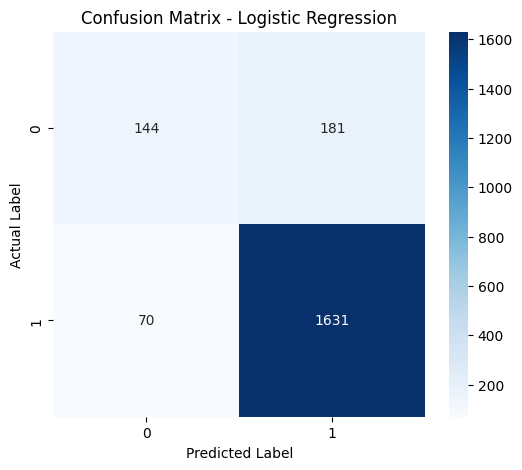

In [11]:
# 오분류 구조를 파악하면 단순 점수 이상의 운영 인사이트를 얻을 수 있다.
# 예를 들어 이탈 고객을 놓치는 비율이 높으면 retention 전략 효과가 떨어질 수 있다.

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 11. ROC Curve 시각화

### 비즈니스 목적
임계값 하나에 고정된 결과뿐 아니라, 다양한 기준에서 모델의 분류 성능이 얼마나 안정적인지 확인한다.  
ROC Curve와 ROC-AUC는 확률 기반 분류 성능을 평가하는 대표 지표로,  
운영 환경에서 임계값을 조정할 여지가 있는지 판단하는 데 도움이 된다.

### 분석 포인트
- 곡선이 좌상단에 가까울수록 좋은 분류 성능을 의미한다.
- ROC-AUC가 높을수록 전반적인 구분 능력이 좋다.
- 실제 운영 시 비즈니스 비용 구조에 맞춰 threshold 조정이 가능하다.

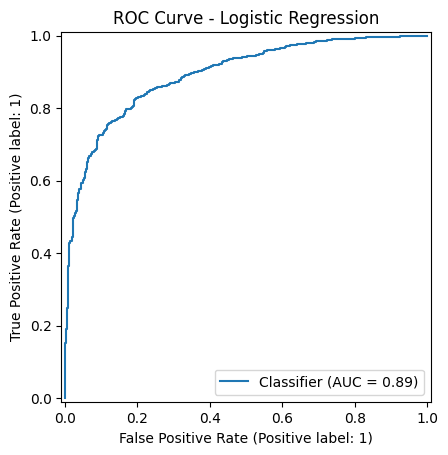

In [12]:
# 확률 기반 분류 성능을 시각적으로 확인한다.
# 모델 배포 후 threshold를 조정해야 하는 경우 ROC 정보가 유용하다.

RocCurveDisplay.from_predictions(y_test, pred_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

## 12. 모델 계수 해석

### 비즈니스 목적
Logistic Regression의 장점은 각 변수의 영향 방향을 해석할 수 있다는 점이다.  
계수를 통해 어떤 변수 값이 커질수록 고객 이탈 확률이 증가하는지,  
반대로 어떤 변수는 이탈 가능성을 낮추는지 파악할 수 있다.

### 분석 포인트
- 계수(+) : 값이 증가할수록 churn 확률 증가 방향
- 계수(-) : 값이 증가할수록 churn 확률 감소 방향
- 절대값이 클수록 상대적으로 영향력이 크다고 볼 수 있다.
- 단, 이는 스케일링된 기준에서 해석해야 한다.

In [13]:
# 계수를 표 형태로 정리하면 어떤 변수가 이탈 확률에 영향을 주는지 빠르게 파악할 수 있다.
# 실무에서는 계수 크기와 함께 도메인 해석이 반드시 병행되어야 한다.

coef = pd.DataFrame({
    "feature": features,
    "coef": log_model.coef_[0]
})

coef = coef.sort_values("coef", ascending=False).reset_index(drop=True)

display(coef)

,feature,coef
0,transaction_count,2.379003
1,count_change,0.794433
2,utilization_ratio,0.708757
3,credit_limit,0.386894
4,contact_count,-0.505902
5,inactive_months,-0.508965
6,transaction_amount,-1.557202


## 13. 변수 영향 시각화

### 비즈니스 목적
표로 보는 계수 결과를 시각화하여, 영향력이 큰 변수를 한눈에 파악한다.  
실무 보고에서는 숫자 표와 함께 막대그래프를 제공하면 비전공자나 협업 부서도 결과를 쉽게 이해할 수 있다.

### 분석 포인트
- 상단 변수일수록 churn 증가 방향의 영향이 큼
- 하단의 음수 계수 변수는 churn 감소 방향으로 작용
- 향후 고객 유지 전략의 우선순위 설정에 활용 가능

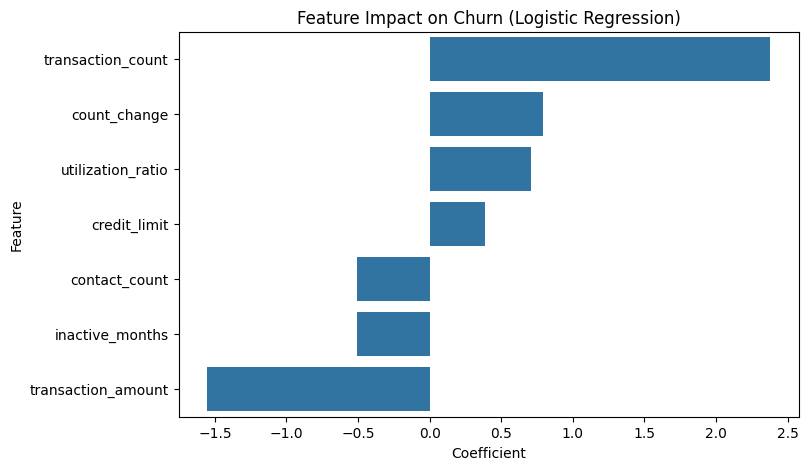

In [14]:
# 시각화를 통해 변수 영향 방향과 상대적 크기를 직관적으로 전달한다.
# 보고용 그래프에서는 제목, 축 이름을 명확히 적어야 해석 오류를 줄일 수 있다.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=coef,
    x="coef",
    y="feature"
)

plt.title("Feature Impact on Churn (Logistic Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## 14. 최종 해석 및 실무 시사점

### 비즈니스 목적
모델 성능과 변수 해석 결과를 종합하여 실제 고객 유지 전략으로 연결 가능한 인사이트를 정리한다.

### 분석 포인트
- 모델은 고객 이탈 여부를 일정 수준 예측할 수 있다.
- 계수 해석을 통해 주요 위험 신호를 파악할 수 있다.
- 향후 임계값 조정, 추가 변수 확장, 클래스 불균형 대응 등을 통해 성능 개선이 가능하다.

### 실무 시사점
- `inactive_months`가 높은 고객은 휴면 전환 가능성이 있으므로 선제적 리텐션 캠페인 대상이 될 수 있다.
- `contact_count`가 높다면 반복 문의 또는 불만 접점 가능성이 있으므로 고객 경험 점검이 필요할 수 있다.
- `transaction_count`, `transaction_amount` 변화는 고객 활성도 저하 신호로 활용될 수 있다.
- 향후에는 Random Forest, XGBoost 등과의 성능 비교도 고려할 수 있다.

In [15]:
# 필요 시 분석 결과를 파일로 저장해 협업이나 보고서 작성에 활용할 수 있다.
# 저장 경로는 실행 환경에 따라 달라질 수 있으므로 상대경로 사용 시 주의한다.

coef.to_csv("logistic_regression_coefficients.csv", index=False, encoding="utf-8-sig")
print("계수 결과 저장 완료: logistic_regression_coefficients.csv")

계수 결과 저장 완료: logistic_regression_coefficients.csv
